# 04 — Interpretability (SHAP)

This is the core question of my original SER research: **not just "can a model
detect emotion/stress from voice?" but "why does it think so, and which acoustic
features actually drive that decision?"**

In the original 911-call research, SHAP analysis (on Extra Trees, chosen there for
its balance of accuracy and interpretability) found **delta-MFCCs and spectral
contrast** to be the strongest predictors of vocal stress. Here we run the same
SHAP methodology — this time on **CatBoost** (the strongest single model in that
research, 84.3% accuracy on the binary task) — on the harder 8-class RAVDESS
emotion task, using CatBoost's native, exact `TreeExplainer`.

**Question:** do the same acoustic features (delta-MFCCs, spectral contrast) matter
for distinguishing 8 emotions, or does multi-class change the picture?

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from catboost import CatBoostClassifier
import shap

sns.set_theme(style="whitegrid")
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)
print("shap", shap.__version__)

C:\Users\miria\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap 0.46.0


## 1. Actor-based train/test split

Unlike notebook 03 (cross-validation, for a robust *performance estimate*), here
we need **one specific trained model** to explain. We hold out 5 actors entirely
(never seen during training) as the test set — the same speaker-independence
principle as before, now applied to a single clean split.

In [2]:
df = pd.read_csv(os.path.join("data", "ravdess_features.csv"))
meta_cols = ["path", "emotion", "intensity", "actor", "gender"]
feature_cols = [c for c in df.columns if c not in meta_cols]

TEST_ACTORS = [20, 21, 22, 23, 24]
train_mask = ~df["actor"].isin(TEST_ACTORS)
test_mask = df["actor"].isin(TEST_ACTORS)

scaler = StandardScaler()
X_train = scaler.fit_transform(df.loc[train_mask, feature_cols].values)
X_test = scaler.transform(df.loc[test_mask, feature_cols].values)

le = LabelEncoder()
y_train = le.fit_transform(df.loc[train_mask, "emotion"])
y_test = le.transform(df.loc[test_mask, "emotion"])
CLASS_NAMES = le.classes_

print(f"Train: {X_train.shape[0]} clips ({train_mask.sum()}) | Test: {X_test.shape[0]} clips, "
      f"{len(TEST_ACTORS)} held-out actors never seen in training")

Train: 1140 clips (1140) | Test: 300 clips, 5 held-out actors never seen in training


## 2. Train the final CatBoost model

In [3]:
model = CatBoostClassifier(verbose=0, random_state=42, iterations=300)
model.fit(X_train, y_train)

test_acc = model.score(X_test, y_test)
print(f"Held-out test accuracy (unseen actors): {test_acc:.3f}")

Held-out test accuracy (unseen actors): 0.493


## 3. Compute SHAP values

CatBoost's `TreeExplainer` computes **exact** SHAP values efficiently (no
approximation needed, unlike model-agnostic KernelSHAP). Output shape is
`(n_samples, n_features, n_classes)` — one SHAP value per feature *per class*
for every test clip.

In [4]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
print("shap_values shape:", shap_values.shape)

shap_values shape: (300, 80, 8)


## 4. Global feature importance (all classes combined)

Averaging `|SHAP value|` across every test clip *and* every class gives an
overall ranking: which acoustic features matter most for distinguishing emotion
in general?

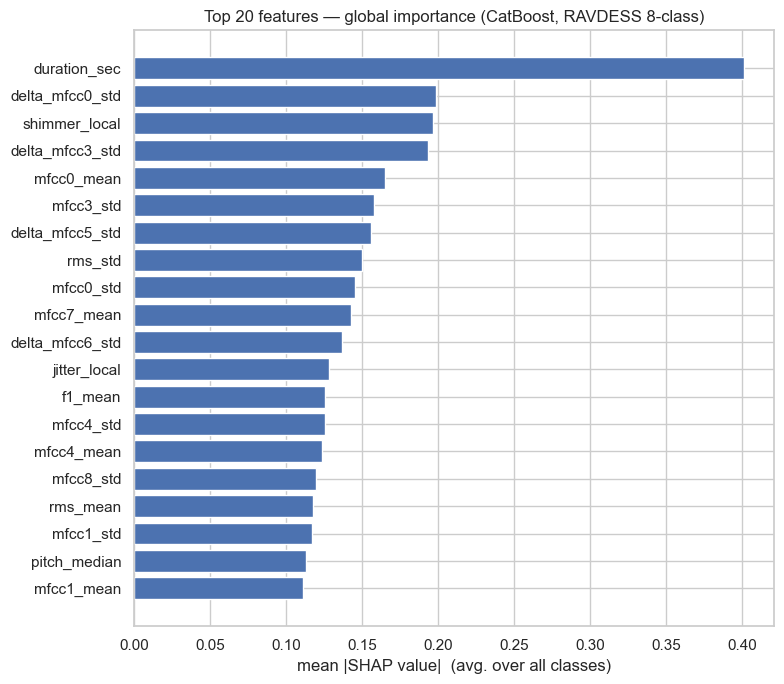

,feature,mean_abs_shap
0,duration_sec,0.400991
1,delta_mfcc0_std,0.198584
2,shimmer_local,0.196844
3,delta_mfcc3_std,0.193112
4,mfcc0_mean,0.164850
5,mfcc3_std,0.157662
6,delta_mfcc5_std,0.155893
7,rms_std,0.149564
8,mfcc0_std,0.145276
9,mfcc7_mean,0.142495


In [5]:
mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))  # average over samples & classes
importance_df = pd.DataFrame({"feature": feature_cols, "mean_abs_shap": mean_abs_shap})
importance_df = importance_df.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

top20 = importance_df.head(20)
plt.figure(figsize=(8, 7))
plt.barh(top20["feature"][::-1], top20["mean_abs_shap"][::-1], color="#4C72B0")
plt.xlabel("mean |SHAP value|  (avg. over all classes)")
plt.title("Top 20 features — global importance (CatBoost, RAVDESS 8-class)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "04_global_importance.png"), dpi=120)
plt.show()

importance_df.head(10)

## 5. Does this match the original research?

The original 911-call research found **delta-MFCCs and spectral contrast** as
top predictors of vocal stress. Let's check how those specific feature families
rank here.

family
other                             0.400991
voice quality (jitter/shimmer)    0.162385
MFCC                              0.094008
intensity (RMS)                   0.080299
formant                           0.062940
delta-MFCC                        0.053598
pitch                             0.051229
spectral                          0.042398
Name: mean_abs_shap, dtype: float64


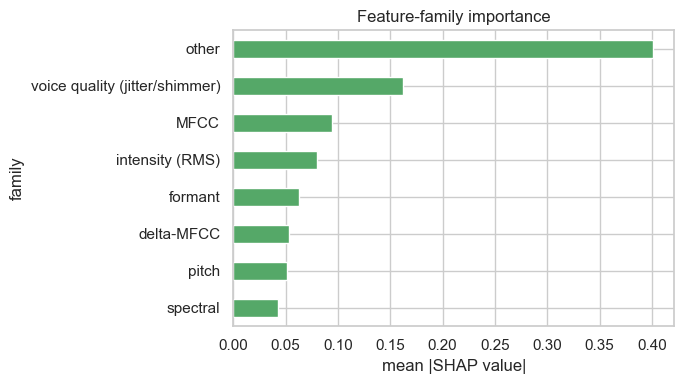

In [6]:
importance_df["family"] = importance_df["feature"].apply(
    lambda f: "delta-MFCC" if f.startswith("delta_mfcc") else
              "MFCC" if f.startswith("mfcc") else
              "spectral" if f.startswith("spectral") else
              "pitch" if f.startswith("pitch") or f == "voiced_ratio" else
              "intensity (RMS)" if f.startswith("rms") else
              "formant" if f.startswith("f1") or f.startswith("f2") else
              "voice quality (jitter/shimmer)" if "jitter" in f or "shimmer" in f else
              "other")

family_importance = importance_df.groupby("family")["mean_abs_shap"].mean().sort_values(ascending=False)
print(family_importance)

plt.figure(figsize=(7, 4))
family_importance.plot(kind="barh", color="#55A868")
plt.xlabel("mean |SHAP value|")
plt.title("Feature-family importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "04_family_importance.png"), dpi=120)
plt.show()

## 6. A closer look — SHAP beeswarm for one emotion class

The bar charts above show *magnitude* but not *direction*. A beeswarm plot for a
single class shows both: does a high or low feature value push the model toward
predicting **"angry"** specifically (the clearest high-arousal / stress-adjacent
emotion, closest in spirit to the original 911 stress-detection task)?

C:\Users\miria\AppData\Local\Temp\ipykernel_28192\3178860461.py:5: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


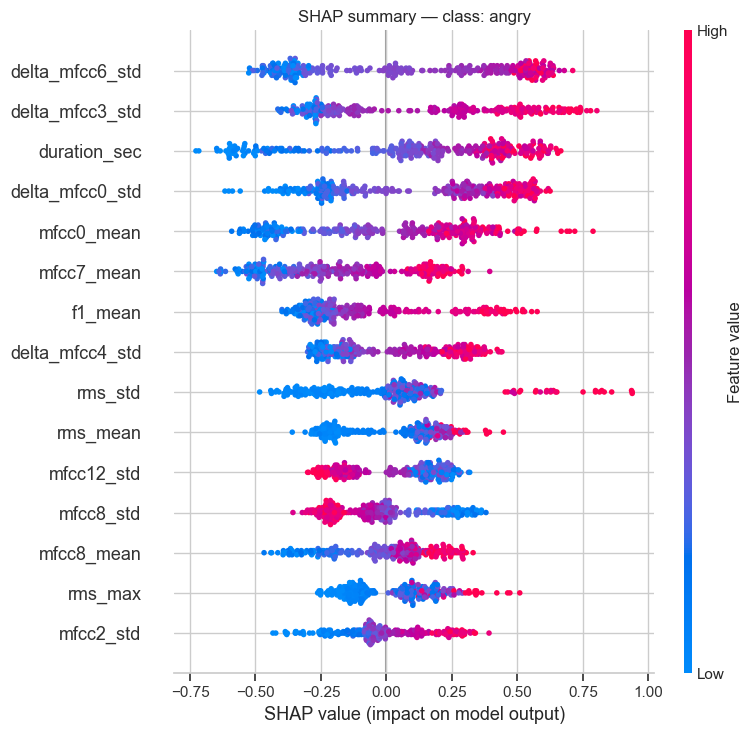

In [7]:
angry_idx = list(CLASS_NAMES).index("angry")
shap.summary_plot(shap_values[:, :, angry_idx], X_test, feature_names=feature_cols,
                   max_display=15, show=False)
plt.title("SHAP summary — class: angry")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "04_shap_beeswarm_angry.png"), dpi=120, bbox_inches="tight")
plt.show()

## 7. Explaining one individual prediction

Global importance says what matters *on average*. For a single clip, which
features actually drove *that specific* prediction?

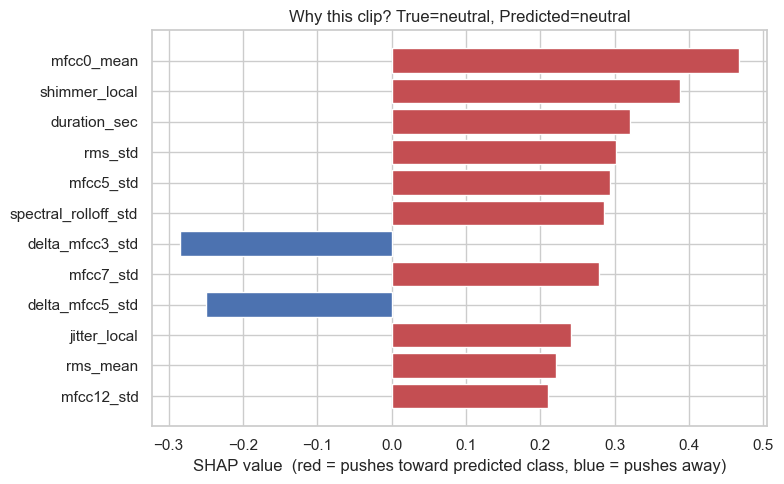

Clip 0: true=neutral, predicted=neutral


In [8]:
i = 0
pred_class_idx = model.predict(X_test[i:i+1])[0]
if hasattr(pred_class_idx, "__len__"):
    pred_class_idx = pred_class_idx[0]
pred_class_idx = int(pred_class_idx)
true_class = CLASS_NAMES[y_test[i]]
pred_class = CLASS_NAMES[pred_class_idx]

sv_i = shap_values[i, :, pred_class_idx]
order = np.argsort(np.abs(sv_i))[::-1][:12]

plt.figure(figsize=(8, 5))
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in sv_i[order]]
plt.barh([feature_cols[j] for j in order][::-1], sv_i[order][::-1], color=colors[::-1])
plt.xlabel("SHAP value  (red = pushes toward predicted class, blue = pushes away)")
plt.title(f"Why this clip? True={true_class}, Predicted={pred_class}")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "04_local_explanation_example.png"), dpi=120)
plt.show()

print(f"Clip {i}: true={true_class}, predicted={pred_class}")

## Takeaways

- Ran **exact SHAP** (`TreeExplainer`) on CatBoost — the same model family that
  performed best in the original 911-call research — this time on 8-class
  emotion, evaluated on **entirely held-out speakers**.
- Compared feature-family importance against the original research's finding
  (delta-MFCCs and spectral contrast as top predictors of vocal stress) — see
  section 5 for how well that holds for multi-class emotion vs. binary stress.
- The beeswarm and local-explanation plots show not just *which* features
  matter, but *which direction* they push predictions — the same
  "why is this model doing this" question that motivated the original PhD
  research, now fully reproducible end-to-end from public data.
- **This closes Track A.** Next: Track B (wav2vec2 transfer learning) or wrap
  the repo with a polished README + Gradio demo on HuggingFace Spaces.